# Class name
# lecturer name
# student name
# topic

In [82]:
# as of oct 31 2024 stable matplotlib version is 3.8.4 -> pip install matplotlib == 3.8.4
try:
    from google.colab import output
    print('Running on CoLab')
    output.enable_custom_widget_manager()
    %pip install ipympl
    %pip install spatialmath-python
    COLAB = True
    SWIFT = False
except ModuleNotFoundError:
    COLAB = False
    SWIFT = False
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"
from IPython.display import HTML

# standard imports
import numpy as np
from scipy import linalg
%matplotlib widget
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *

1. Frame {A} and Frame {B} are initially coincident. Frame {B} is rotated initially
around unit vector $𝑥̂^{𝐵}$ , by and angle 𝜃 and then around $𝑧̂^{𝐵}$ by angle 𝛼. Calculate the
3 × 3 rotation matrix $𝑅_{𝐵}^{𝐴}$ that describes the orientation of frame {B} with respect to
the frame {A}.

$$ \widehat{B}_{x,\theta} =
            \left(\begin{array}{cc}
            1 & 0 & 0\\
            0 & c\theta & -s\theta\\
            0 & s\theta & c\theta
            \end{array}\right)
$$
$$
    \widehat{B}_{z,\alpha} = 
            \left(\begin{array}{cc}
            c\alpha & -s\alpha & 0\\
            s\alpha & c\alpha & 0\\
            0 & 0 & 1
            \end{array}\right)
$$

$$ R_{B}^{A} = \widehat{B}_{x,\theta} \widehat{B}_{z,\alpha} = 

            \left(\begin{array}{cc}
            c\alpha & -s\alpha & 0\\
            c\theta s\alpha & c\theta c\alpha & -s\alpha\\
            s\theta s\alpha& s\theta c\alpha & c\theta
            \end{array}\right)

$$

2. Suppose we have 𝜃 = 45° and 𝛼 = 30°. A point is given in Frame {B} with
coordinate vector $p^{B} = [3, 4, 5]^{𝑇}$ . Analytically calculate its coordinate
representation in Frame {A}.

$$ R_{B}^{A} = \widehat{B}_{x,\theta} \widehat{B}_{z,\alpha} = 

            \left(\begin{array}{cc}
            c\alpha & -s\alpha & 0\\
            c\theta s\alpha & c\theta c\alpha & -s\alpha\\
            s\theta c\alpha& s\theta c\alpha & c\theta
            \end{array}\right)

$$

$$
    P^{A} = R_{B}^{A} P^{B} = 

            \left(\begin{array}{cc}
            c30 & -s30 & 0\\
            c45 s30 & c45 c30 & -s45\\
            s45 s30& s45 c30 & c45
            \end{array}\right)

            \left(\begin{array}{cc}
            3\\
            4\\
            5
            \end{array}\right)

$$

$$ =
            \left(\begin{array}{cc}
            3 \frac{\sqrt{3}}{2}+-\frac{4}{2}+0\\
            \frac{\sqrt{2}}{2}*\frac{1}{2}*3+\frac{\sqrt{2}}{2}*\frac{\sqrt{3}}{2}*4 -\frac{\sqrt{2}}{2}*5\\
            \frac{\sqrt{(2)}}{2}*\frac{1}{2}*3 + \frac{\sqrt{2}}{2}*\frac{\sqrt{3}}{2}*4 + \frac{\sqrt{2}}{2}*5
            \end{array}\right)

            = 

            \left(\begin{array}{cc}
            0.5981\\
            -0.0254\\
            7.0457
            \end{array}\right)

$$


3. Suppose the same coordinates were given for a point $q^{A}$ in Frame {A}. Calculate the
coordinates of this point in frame {B}. How did you use the result in (1) to make this
calculation?

So we multiply $p^{B}$ with rotation matrix to find its relative position to the A frame and add it to our Homogeneous transformation 4th column.

$$ H^{A}_{B} =
            \left(\begin{array}{cc}
            R_{B}^{A} & P^{A}\\
            0 & 1
            \end{array}\right)

$$

$$ H^{A}_{B} = 

            \left(\begin{array}{cc}
            c30 & -s30 & 0 & 0.5981\\
            c45 s30 & c45 c30 & -s45 & -0.0254\\
            s45 s30& s45 c30 & c45 & 7.0457\\
            0 & 0 & 0 & 1
            \end{array}\right)


$$

4. Now again, consider Frames {A} and {B} coincident. Frame {B} is now rotated
initially around unit vector $𝑥̂^{𝐴}$ , by and angle 𝜃 and then around $𝑧̂^{𝐴}$ by angle 𝛼. Again
calculate the 3 × 3 rotation matrix $𝑅_{𝐵}^{𝐴}$ that describes the orientation of frame {B} with
respect to the frame {A}. Does you result coincide with the result in (1)? Explain.

-> Rotation w.r.t current frame result should be: $R_{2}^{0}= R_{1}^{0}R_{2}^{1} = R_{1}^{0}(R_{1}^{0})^{-1}R(R_{1}^{0})= RR_{1}^{0}$ Which means Fixed Rotations are Premultiplied from the left.

$R^{A}_{B} = B_{z,\alpha}B_{x,\theta}$ =

$$    
            \left(\begin{array}{cc}
            c\alpha & -s\alpha & 0\\
            s\alpha & c\alpha & 0\\
            0 & 0 & 1
            \end{array}\right)


            \left(\begin{array}{cc}
            1 & 0 & 0\\
            0 & c\theta & -s\theta\\
            0 & s\theta & c\theta
            \end{array}\right)
            
            =

           \left(\begin{array}{cc}
            c\theta & -s\alpha c\theta & s\alpha s\theta\\
            s\alpha & c\alpha c\theta & -c\alpha s\theta\\
            0 & s\theta & c\theta
            \end{array}\right)
$$

$$
            \left(\begin{array}{cc}
            c30 & -s30 c45 & s30 s45\\
            s30 & c30 c45 & -c30 s45\\
            0 & s45 & c45
            \end{array}\right)
$$

since we are multiplying our rotations in different order, the result should differ from non Fixed frame

5. Consider the basic rotations described in (1) with 𝜃 and 𝛼 values given in (2). Create
the corresponding basic rotation matrices using the two alternative toolbox functions,
e.g., **SO(3).Rx()** and **rotx()** with the proper axes specified. Use the computer to
calculate the overall rotation matrix $𝑅_{𝐵}^{𝐴}$ . (Note: How do you multiply matrices with
Python3 and numpy package?) Verify your results in (2) and (3).

In [83]:
# theta = 45    | alpha = 30
# theta =  pi/4 | alpha = pi/6

theta = pi/4
alpha = pi/6




0.5235987755982988

In [84]:
Rx= SO3.Rx(theta)
type2 = type(Rx)
print(Rx)

   1         0         0         
   0         0.7071   -0.7071    
   0         0.7071    0.7071    



In [85]:
Rz = SO3.Rz(alpha)

   0.866    -0.5       0         
   0.5       0.866     0         
   0         0         1         


In [86]:
Rotso3 = Rx * Rz

   0.866    -0.5       0         
   0.3536    0.6124   -0.7071    
   0.3536    0.6124    0.7071    


In [87]:
Rx = rotx(theta)
type1 = type(Rx)
print(Rx)

[[       1        0        0]
 [       0   0.7071  -0.7071]
 [       0   0.7071   0.7071]]


In [88]:
Rz = rotz(alpha,"rad") #rad or deg

array([[   0.866,     -0.5,        0],
       [     0.5,    0.866,        0],
       [       0,        0,        1]])

In [89]:
Rot = Rx @ Rz

array([[   0.866,     -0.5,        0],
       [  0.3536,   0.6124,  -0.7071],
       [  0.3536,   0.6124,   0.7071]])

6. Identify (how in python3?) the data types of the rotation matrices obtained with the
two alternative versions of creating the rotation matrices.

In [90]:
print('Data type for rot function is:' ,type1, "\nfor SO3 function is:", type2 )

Data type for rot function is: <class 'numpy.ndarray'> 
for SO3 function is: <class 'spatialmath.pose3d.SO3'>


In [105]:
A= rotx(0)

array([[       1,        0,        0],
       [       0,        1,        0],
       [       0,        0,        1]])

7. Explore the options of your chosen plotting function SO(3).plot() or trplot()
such as specifying the Frame label, color, coordinate range etc. Now plot

a. The original frame {A},

b. The intermediate frames {𝐴1 } and {𝐴2 } resulting from the two basic rotations,

c. The final Frame {B}.

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

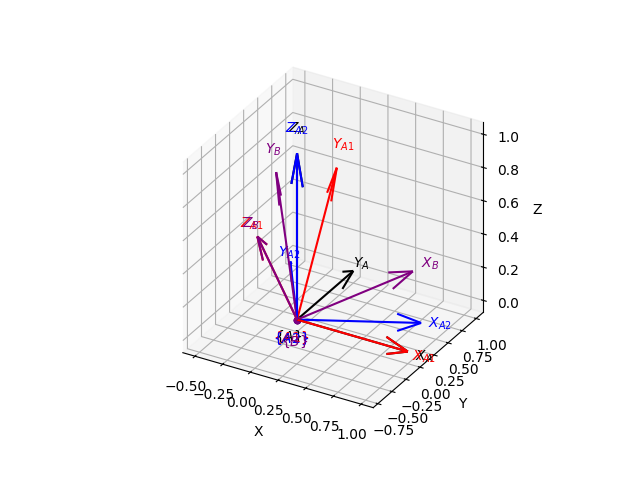

In [109]:
plotvol3(new=True)
trplot(A,color='black',frame='A') #A
trplot(Rx,color='red',frame='A1') #A1
trplot(Rz,color='blue',frame='A2') #A2
trplot(Rot,color='purple',frame='B') #B

8. Use **tranimate()** to animate the overall rotation from Frame {A} to Frame {B}. 
(There is also a **SO(3).animate()** version).

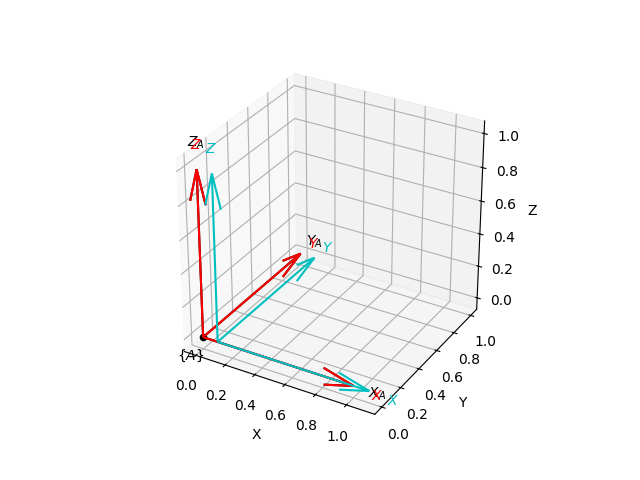

In [110]:
plotvol3(new=True)
trplot(A,color='black',frame='A')
tranimate(Rot,anaglyph=True)

9. Given the Homogeneous transformation matrix

$$ T^{B}_{A} = 

            \left(\begin{array}{cc}
            1 & 0 & 0 & 1\\
            0 & cos(\theta) & -sin(\theta) & 2\\
            0 & sin(\theta) & cos(\theta) & 3\\
            0 & 0 & 0 & 1
            \end{array}\right)


$$

a. Analytically find the homogeneous transformation $T_{B}^{A}$.

b. Given $\theta = 45^{o}$ and a point $p^{B} = [3,4,5]^{T}$ in frame {B}, compute the coordinates $p^{A}$ in Frame {A}. 

$$ H^{A}_{B} =
            \left(\begin{array}{cc}
            R_{B}^{A} & P^{A}\\
            0 & 1
            \end{array}\right)

$$

$$ H^{-1} =
            \left(\begin{array}{cc}
            R^{T} & -R^{T}.p^{B} \\
            0 & 1
            \end{array}\right)

$$

10. Show that $\in$ SO(3), namely it is a Rotation Matrix.

$$ T = 

            \left(\begin{array}{cc}
            \frac{1}{\sqrt{2}} & 0 & \frac{1}{\sqrt{2}}\\
            -\frac{1}{2} & \frac{1}{\sqrt{2}} & \frac{1}{2} \\
            -\frac{1}{2} & -\frac{1}{\sqrt{2}} & \frac{1}{2}
            \end{array}\right)


$$

**Programming Task:**

11. Animate a rotating cube:

a. Write a function to plot the edges of a cube centered at the origin. (Note: You will need the **mplot3d** extensions to the **matplotlib** package in Python3)

b. Modify the function to accept an argument which is a homogeneous transformation that is applied the the cube vertices before plotting.

c. Animate rotation about the x-axis.

d. Animate rotation about all axes.